### Setup

In [1]:
import sys
import os
sys.path.append("../")
sys.path.append("../..")

In [2]:
import math

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from scale_rl.common.wandb_utils import *

In [4]:
from color import METHOD_COLORS, METHOD_BOUNDARY_COLORS, BORDER_GRAY

In [5]:
from scale_rl.envs.humanoid_bench import HB_LOCOMOTION_NOHAND, HB_SUCCESS_SCORE, HB_RANDOM_SCORE

def replace_underbar_to_hypen(env_name_list):
    for idx in range(len(env_name_list)):
        env_name_list[idx] = env_name_list[idx].replace('_', '-')
    return env_name_list

def replace_underbar_to_hypen_dict(env_name_dict):
    _new_dict = {}
    for k, v in env_name_dict.items():
        _new_dict[k.replace('_', '-')] = v
    return _new_dict

/home/nas4_user/youngdolee/anaconda3/envs/scale_rl/lib/python3.9/site-packages/glfw/__init__.py:916: GLFWError: (65544) b'X11: The DISPLAY environment variable is missing'
  warnings.warn(message, GLFWError)


In [6]:
HB_LOCOMOTION_NOHAND = replace_underbar_to_hypen(HB_LOCOMOTION_NOHAND)
HB_SUCCESS_SCORE = replace_underbar_to_hypen_dict(HB_SUCCESS_SCORE)
HB_RANDOM_SCORE = replace_underbar_to_hypen_dict(HB_RANDOM_SCORE)

# Remove manipulation & with-hand tasks
HB_SUCCESS_SCORE = {k: v for k, v in HB_SUCCESS_SCORE.items() if k in HB_LOCOMOTION_NOHAND}
HB_RANDOM_SCORE = {k: v for k, v in HB_RANDOM_SCORE.items() if k in HB_LOCOMOTION_NOHAND}

HB_STEPS = 1000000 # 1M

In [7]:
def normalize_score_with_random_and_base_score(
    df: pd.DataFrame, random_score_dict: dict, base_score_dict: dict
) -> pd.DataFrame:
    """
    Normalize the 'value' column based on random and base scores.
        normalized_value = (value - random_score) / (base_score - random_score)

    Args:
    - df (pd.DataFrame): DataFrame with 'env_name' and 'value' columns.
    - random_score_dict (dict): Mapping of 'env_name' to random scores.
    - base_score_dict (dict): Mapping of 'env_name' to base scores.

    Returns:
    - pd.DataFrame: DataFrame with an added 'normalized_value' column.
    """
    # Create a copy of the DataFrame to avoid modifying the original
    df_normalized = df.copy()

    # Define a function to normalize a single value
    def normalize_value(row):
        env_name = row["env_name"]
        value = row["value"]
        base_score = base_score_dict[env_name]
        random_score = random_score_dict[env_name]

        return (value - random_score) / (base_score - random_score)

    # Apply the normalization function to each row
    df_normalized["value"] = df_normalized.apply(normalize_value, axis=1)

    return df_normalized

### Load Simba+ & SimbaV2

In [8]:
entity = 'draftrec'
project_name = 'Simba_2502'
run_exp_names_to_analysis_exp_names = {
    'hypersimba_hb_metrics_rr8': 'SimbaV2_rr8',
}
run_exp_names = list(run_exp_names_to_analysis_exp_names.keys())
metrics = ['avg_return', 'critic_encoder/effective_pnorm_total', 'critic_encoder/effective_gnorm_total', 'critic_encoder/effective_lr_total',  'critic_encoder/effective_fnorm_total', 'critic_predictor/effective_pnorm_total', 'critic_predictor/effective_gnorm_total', 'critic_predictor/effective_lr_total',  'critic_predictor/effective_fnorm_total', 'critic/effective_pnorm_total', 'critic/effective_gnorm_total', 'critic/effective_lr_total',  'critic/effective_fnorm_total']

In [9]:
# Load from wandb
runs = collect_runs(entity=entity, project_name=project_name) 
filtered_runs = filter_runs(runs, exp_names = run_exp_names)
wandb_df = convert_runs_to_dataframe(
    runs = filtered_runs, 
    run_exp_name_to_analysis_exp_name=run_exp_names_to_analysis_exp_names
)
wandb_df = wandb_df[wandb_df.apply(lambda row: 'finished' in str(row['run']), axis=1)]

  0%|          | 0/151 [00:00<?, ?it/s]

  0%|          | 0/26 [00:00<?, ?it/s]

In [10]:
eval_df = convert_wandb_df_to_eval_df(wandb_df, metrics)
eval_df

  0%|          | 0/24 [00:00<?, ?it/s]

,exp_name,env_name,seed,metric,env_step,value
0,SimbaV2_rr8,h1-sit_hard-v0,3000,avg_return,0.0,6.283629
1,SimbaV2_rr8,h1-sit_hard-v0,3000,avg_return,100000.0,401.748808
2,SimbaV2_rr8,h1-sit_hard-v0,3000,avg_return,200000.0,735.406042
3,SimbaV2_rr8,h1-sit_hard-v0,3000,avg_return,300000.0,676.060430
4,SimbaV2_rr8,h1-sit_hard-v0,3000,avg_return,400000.0,837.825069
...,...,...,...,...,...,...
3427,SimbaV2_rr8,h1-walk-v0,0,critic/effective_fnorm_total,600000.0,2.734021
3428,SimbaV2_rr8,h1-walk-v0,0,critic/effective_fnorm_total,700000.0,2.691981
3429,SimbaV2_rr8,h1-walk-v0,0,critic/effective_fnorm_total,800000.0,2.660531
3430,SimbaV2_rr8,h1-walk-v0,0,critic/effective_fnorm_total,900000.0,2.621680


In [11]:
eval_df['env_name'] = eval_df['env_name'].str.replace('_', '-')
eval_df = eval_df[eval_df["env_name"].isin(HB_LOCOMOTION_NOHAND)]
eval_df

,exp_name,env_name,seed,metric,env_step,value
0,SimbaV2_rr8,h1-sit-hard-v0,3000,avg_return,0.0,6.283629
1,SimbaV2_rr8,h1-sit-hard-v0,3000,avg_return,100000.0,401.748808
2,SimbaV2_rr8,h1-sit-hard-v0,3000,avg_return,200000.0,735.406042
3,SimbaV2_rr8,h1-sit-hard-v0,3000,avg_return,300000.0,676.060430
4,SimbaV2_rr8,h1-sit-hard-v0,3000,avg_return,400000.0,837.825069
...,...,...,...,...,...,...
3427,SimbaV2_rr8,h1-walk-v0,0,critic/effective_fnorm_total,600000.0,2.734021
3428,SimbaV2_rr8,h1-walk-v0,0,critic/effective_fnorm_total,700000.0,2.691981
3429,SimbaV2_rr8,h1-walk-v0,0,critic/effective_fnorm_total,800000.0,2.660531
3430,SimbaV2_rr8,h1-walk-v0,0,critic/effective_fnorm_total,900000.0,2.621680


In [12]:
eval_df[eval_df["metric"] == "avg_return"] = normalize_score_with_random_and_base_score(eval_df[eval_df["metric"] == "avg_return"], HB_RANDOM_SCORE, HB_SUCCESS_SCORE)

In [13]:
eval_df[eval_df["metric"] == "avg_return"]["value"]

0       0.005131
1       0.534145
2       0.980478
3       0.901091
4       1.117484
          ...   
3295    1.202910
3296    1.204343
3297    1.208252
3298    1.206620
3299    1.210814
Name: value, Length: 264, dtype: float64

In [14]:
eval_df["exp_name"].unique()

array(['SimbaV2_rr8'], dtype=object)

In [15]:
eval_df["metric"].unique()

array(['avg_return', 'critic_encoder/effective_pnorm_total',
       'critic_encoder/effective_gnorm_total',
       'critic_encoder/effective_lr_total',
       'critic_encoder/effective_fnorm_total',
       'critic_predictor/effective_pnorm_total',
       'critic_predictor/effective_gnorm_total',
       'critic_predictor/effective_lr_total',
       'critic_predictor/effective_fnorm_total',
       'critic/effective_pnorm_total', 'critic/effective_gnorm_total',
       'critic/effective_lr_total', 'critic/effective_fnorm_total'],
      dtype=object)

In [16]:
simbav2_marker = 'o'
simba_marker = 'o'

markers = {
    'SimbaV2_rr8': simbav2_marker,
    'SimbaV2_rr8_encoder': simbav2_marker,
    'SimbaV2_rr8_predictor': simbav2_marker,
    # 'Simba+': simba_plus_marker,
    'Simba': simba_marker,
    'Simba_encoder': simba_marker,
    'Simba_predictor': simba_marker,
}

In [17]:
simbav2_color = METHOD_BOUNDARY_COLORS["SimbaV2"] # sns.color_palette("YlOrBr",20)[8]
simbav2_alpha_color = METHOD_COLORS["SimbaV2"] # (*simba_color, 0.2)
# Mine
# simba_color = "#feb600" #  METHOD_BOUNDARY_COLORS["Simba"] # sns.color_palette("YlOrBr",20)[8]
# simba_alpha_color = "#feb600" # METHOD_COLORS["Simba"] # (*simba_color, 0.2)
simba_color = "#F6CC64"
simba_alpha_color = "#f8d48c"


simbav2_encoder_color = "#8cb0f8"
simbav2_encoder_alpha_color = "#8cb0f8"
simbav2_predictor_color = "#0453fb"
simbav2_predictor_alpha_color = "#0453fb"

# simba_encoder_color = "#F8D48B"
# simba_encoder_alpha_color = "#F8D48B"
# simba_predictor_color = "#EACA57"
# simba_predictor_alpha_color = "#EACA57"
# simba_predictor_tick_color = "#EACA57"

simba_encoder_color = "#f8d48c" # "#ffd527"
simba_encoder_alpha_color = "#f8d48c" # "#ffd527"
simba_predictor_color = "#fbac04" # "#ffa500"
simba_predictor_alpha_color = "#fbac04" # "#ffa500"
simba_predictor_tick_color = "#fb8704" # "#ffa500"

BORDER_GRAY = "#D3D3D3"
colors = {
    'SimbaV2_rr8': simbav2_color,
    'SimbaV2_rr8_encoder': simbav2_encoder_color,
    'SimbaV2_rr8_predictor': simbav2_predictor_color,
    # 'Simba+': simba_plus_color,
    'Simba': simba_color, 
    'Simba_encoder': simba_encoder_color,
    'Simba_predictor': simba_predictor_color,
    'Simba_predictor_tick': simba_predictor_tick_color,
}

In [18]:
import matplotlib.lines as mlines
simbav2_legend = mlines.Line2D([], [], color=simbav2_alpha_color, markeredgecolor=simbav2_color, marker=simbav2_marker, linestyle='None', markersize=14, label='SimbaV2')
simbav2_encoder_legend = mlines.Line2D([], [], color=simbav2_encoder_alpha_color, markeredgecolor=simbav2_encoder_color, marker=simbav2_marker, linestyle='None', markersize=14, label='SimbaV2 Encoder')
simbav2_predictor_legend = mlines.Line2D([], [], color=simbav2_predictor_alpha_color, markeredgecolor=simbav2_predictor_color, marker=simbav2_marker, linestyle='None', markersize=14, label='SimbaV2 Predictor')

simba_legend = mlines.Line2D([], [], color=simba_alpha_color, markeredgecolor=simba_color, marker=simba_marker, linestyle='None', markersize=14, label='Simba')
simba_encoder_legend = mlines.Line2D([], [], color=simba_encoder_alpha_color, markeredgecolor=simba_encoder_color, marker=simba_marker, linestyle='None', markersize=14, label='Simba Encoder')
simba_predictor_legend = mlines.Line2D([], [], color=simba_predictor_alpha_color, markeredgecolor=simba_predictor_color, marker=simba_marker, linestyle='None', markersize=14, label='Simba Predictor')

legend_handles = {
    'SimbaV2': simbav2_legend,
    'SimbaV2 Encoder': simbav2_encoder_legend,
    'SimbaV2 Predictor': simbav2_predictor_legend,
    'Simba': simba_legend, 
    'Simba Encoder': simba_encoder_legend,
    'Simba Predictor': simba_predictor_legend,
    # 'Simba+': simba_plus_legend, 
}

# For plot
marker_sizes_all = {
    'SimbaV2_rr8': 125,
    'SimbaV2_rr8_encoder': 125,
    'SimbaV2_rr8_predictor': 125,
    # 'Simba+': 150,
    'Simba': 125,
    'Simba_encoder': 125,
    'Simba_predictor': 125,
}
marker_sizes = {
    'SimbaV2_rr8': 125,
    'SimbaV2_rr8_encoder': 125,
    'SimbaV2_rr8_predictor': 125,
    # 'Simba+': 125,
    'Simba': 125,
    'Simba_encoder': 125,
    'Simba_predictor': 125,
}

### Visualization

### Total

In [19]:
TITLE_FONTSIZE = 18
TICK_FONTSIZE = 16
OFFSET_FONTSIZE = 14
LABEL_FONTSIZE = 18

SUBTITLE_MARGIN = 1.10

In [20]:
def simple_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

In [21]:
def subplot_effective_lr_total(
    ax,
    experiments,
    metrics,
    prefixes,
    metric_data,
    colors,
    num_x_ticks: int = 6,
    num_y_ticks: int = 5,
    x_label: str = "Env steps (M)",
    line_width: float = 2.5,
    y_lim_mins: dict = {"encoder": 0, "predictor": 0},
    y_lim_maxs: dict = {"encoder": 4e-3, "predictor": 4e-3},
    simbav2_lr: float = 1e-3
):  
    sns.set_style('whitegrid')    
    ax.yaxis.set_major_locator(plt.MaxNLocator(num_y_ticks, integer=True))
    ax.yaxis.grid(True, linestyle='--', linewidth=1.0, alpha=1.0)
    for i, _metric in enumerate(metrics):
        prefix = prefixes[i]
        y_lim_min, y_lim_max = y_lim_mins[prefix], y_lim_maxs[prefix]
        _metric_data = metric_data[metric_data["metric"] == _metric]
        
        for exp in experiments:
            exp_data = _metric_data[_metric_data["exp_name"] == exp]
            if len(exp_data) == 0:
                continue
            
            # Group by env_step and calculate mean across all environments
            grouped_data = exp_data.groupby(["env_step"])["value"]
            env_steps = grouped_data.mean().index.values
            mean = grouped_data.mean().values
            std_error = grouped_data.sem().values  # Standard error of the mean

            # Plot mean history with thicker lines
            if exp == 'SimbaV2':
                zorder = 20
            else:
                zorder = 10
            
            ax.tick_params(axis='y', color='white', labelsize=TICK_FONTSIZE)
            y_len = y_lim_max - y_lim_min
            ax.set_ylim(-0.1 * y_len, y_lim_max + 0.1 * y_len)
            
            y_ticks = np.linspace(0, y_lim_max, num_y_ticks)
            ax.set_yticks(y_ticks)
            import matplotlib.ticker as mticker
            formatter = mticker.ScalarFormatter(useMathText=True)
            formatter.set_powerlimits((1, 2))
            ax.yaxis.set_major_formatter(formatter)
            ax.yaxis.get_offset_text().set_fontsize(OFFSET_FONTSIZE)
            
            exp = f"{exp}_{prefix}"
            
            ax.plot(env_steps, 
                    mean, 
                    linewidth=line_width, 
                    marker=markers[exp], 
                    markevery=2,
                    color=colors[exp], 
                    zorder=zorder)
            
            ax.fill_between(
                env_steps,
                mean - 1.96 * std_error,
                mean + 1.96 * std_error,
                alpha=0.2,
                color=colors[exp],
                label=None,)

        # Set labels and limits
        ax.set_xlabel(x_label, fontsize=TICK_FONTSIZE)
        
        # Set x-ticks and format them
        x_ticks = np.linspace(0, 1e6, num_x_ticks)
        ax.set_xticks(x_ticks)
        # Format x-tick labels
        x_tick_labels = []
        for tick in x_ticks:
            if tick == 0:
                x_tick_labels.append("0")
            else:
                x_tick_labels.append("{:.1f}".format(tick / 1e6))
        
        ax.set_xticklabels(x_tick_labels, fontsize=TICK_FONTSIZE)
        
        ax.set_autoscale_on(False)
        ax.xaxis.set_major_locator(plt.MaxNLocator(num_x_ticks, integer=True))
        ax.xaxis.grid(True, linestyle='--', linewidth=1.0, alpha=1.0)
        simple_axis(ax)
    
    # Add custom title with first line bold
    title = "Effective Learning Rate"
    ax.set_title('')  # Clear any existing title
    ax.text(0.5, SUBTITLE_MARGIN, title, color="black", transform=ax.transAxes, ha='center', va='bottom', fontsize=TITLE_FONTSIZE,)

In [22]:
def plot_analysis_metrics_total(
    eval_df,
    env_names: list,
    colors,
    metrics: list,
    metrics_to_title: list,
    bbox_to_anchor_left: tuple,
    bbox_to_anchor_right: tuple,
    num_x_ticks: int = 6,
    num_y_ticks: int = 5,
    x_label: str = "Env steps (M)",
    plot_width: int = 20,
    plot_height: int = 3,
    wspace: float = 0.3,
    hspace: float = 0.5,
    line_width: float = 2.5,
    y_lim_mins: list = [0, 1, 20, 0, None],
    y_lim_maxs: list = [1, 40, 60, 0.1, None],
    main_title: str = "DMC-Hard",
    columns: list = ["SimbaV2_rr8", "Simba"],
):  
    env_data = eval_df[eval_df["env_name"].isin(env_names)]
    experiments = env_data["exp_name"].unique()
    assert sorted(columns) == sorted(experiments)
    num_plots = 5
    ncols = 5
    nrows = (num_plots + ncols - 1) // ncols  # Calculate number of rows needed
    
    # Set up the figure
    # sns.set_style('darkgrid', {"axes.facecolor": "white", "grid.color": BORDER_GRAY})
    sns.set_style('whitegrid')    
    
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(plot_width, plot_height), squeeze=False)
    fig.subplots_adjust(hspace=hspace, wspace=wspace)
    axs = axs.flatten()  # Flatten in case of a single subplot
    
    # Start plotting
    for i, metric in enumerate(metrics):
        ax = axs[i]
        y_lim_min, y_lim_max = y_lim_mins[i], y_lim_maxs[i]
        
        # For avg return
        if i == 0:
            metric_data = env_data[env_data["metric"] == metric]
            
            for exp in columns:
                exp_data = metric_data[metric_data["exp_name"] == exp]
                if len(exp_data) == 0:
                    continue  
                
                # Check if env_step = 0 exists, if not, add it with value 0
                if 0 not in exp_data["env_step"].values:
                    default_value = 0
                    zero_row = pd.DataFrame({
                        "env_step": [0],
                        "value": [default_value],
                        "exp_name": [exp],
                        "metric": [metric]
                    })
                    exp_data = pd.concat([zero_row, exp_data]).reset_index(drop=True)
                    
                # Group by env_step and calculate mean across all environments
                grouped_data = exp_data.groupby(["env_step"])["value"]
                env_steps = grouped_data.mean().index.values
                mean = grouped_data.mean().values
                std_error = grouped_data.sem().values  # Standard error of the mean

                # Plot mean history with thicker lines
                if exp == 'SimbaV2':
                    zorder = 20
                else:
                    zorder = 10

                ax.plot(env_steps, 
                        mean, 
                        label=exp, 
                        marker=markers[exp], 
                        markevery=2,
                        linewidth=line_width, 
                        color=colors[exp], 
                        zorder=zorder)
                
                # Fill between mean - std_error and mean + std_error
                ax.fill_between(
                    env_steps,
                    mean - 1.96 * std_error,
                    mean + 1.96 * std_error,
                    alpha=0.2,
                    label=None,
                    color=colors[exp],
                )
                ax.xaxis.set_major_locator(plt.MaxNLocator(num_x_ticks, integer=True))
                ax.yaxis.set_major_locator(plt.MaxNLocator(num_y_ticks, integer=True))
                ax.xaxis.grid(True, linestyle='--', linewidth=1.0, alpha=1.0)
                ax.yaxis.grid(True, linestyle='--', linewidth=1.0, alpha=1.0)
                simple_axis(ax)
        
        # For bottom subplots
        else:
            if metric == "effective_lr_total":
                metric_data = env_data[env_data["metric"].isin(['critic_encoder/' + metric, 'critic_predictor/' + metric])]
                metrics = ['critic_encoder/' + metric, 'critic_predictor/' + metric]
                prefixes = ['encoder', 'predictor']
                subplot_effective_lr_total(
                    ax,
                    experiments,
                    metrics,
                    prefixes,
                    metric_data,
                    colors)
                continue
            else: 
                if 'total' in metric:
                    _metrics = ['critic_encoder/' + metric, 'critic_predictor/' + metric]
                    _exp_prefixes = ['encoder', 'predictor']
                else: 
                    _metrics = [metric]
                    _exp_prefixes = [None]
                    
            for j, _metric in enumerate(_metrics):
                metric_data = env_data[env_data["metric"] == _metric]
                _exp_prefix = _exp_prefixes[j]
                
                for exp in columns:
                    exp_data = metric_data[metric_data["exp_name"] == exp]
                    if len(exp_data) == 0:
                        continue  
                    
                    # Check if env_step = 0 exists, if not, add it with value 0
                    if 0 not in exp_data["env_step"].values:
                        if metric in ["avg_return", "avg_discounted_return", "avg_estimate_q"]: 
                            default_value = 0
                            zero_row = pd.DataFrame({
                                "env_step": [0],
                                "value": [default_value],
                                "exp_name": [exp],
                                "metric": [metric]
                            })
                            exp_data = pd.concat([zero_row, exp_data]).reset_index(drop=True)
                        
                        
                    # Group by env_step and calculate mean across all environments
                    grouped_data = exp_data.groupby(["env_step"])["value"]
                    env_steps = grouped_data.mean().index.values
                    mean = grouped_data.mean().values
                    std_error = grouped_data.sem().values  # Standard error of the mean

                    # Plot mean history with thicker lines
                    if exp == 'SimbaV2':
                        zorder = 20
                    else:
                        zorder = 10
                
                    if _exp_prefix:
                        plot_label = f"{exp} {_exp_prefix.capitalize()}"
                        exp = f"{exp}_{_exp_prefix}"
                        
                    ax.plot(env_steps, 
                            mean, 
                            label=plot_label,
                            marker=markers[exp], 
                            markevery=2, 
                            linewidth=line_width, 
                            color=colors[exp], 
                            zorder=zorder)
                    
                    
                    # Fill between mean - std_error and mean + std_error
                    ax.fill_between(
                        env_steps,
                        mean - 1.96 * std_error,
                        mean + 1.96 * std_error,
                        alpha=0.2,
                        color=colors[exp],
                        label=None,
                    )
                    ax.xaxis.set_major_locator(plt.MaxNLocator(num_x_ticks, integer=True))
                    ax.yaxis.set_major_locator(plt.MaxNLocator(num_y_ticks, integer=True))
                    ax.xaxis.grid(True, linestyle='--', linewidth=1.0, alpha=1.0)
                    ax.yaxis.grid(True, linestyle='--', linewidth=1.0, alpha=1.0)
                    simple_axis(ax)
        
                
        # Set labels and limits
        ax.set_xlabel(x_label, fontsize=TICK_FONTSIZE)

        # Set x-ticks and format them
        x_ticks = np.linspace(0, 1e6, num_x_ticks)
            
        ax.set_xticks(x_ticks)
        # Format x-tick labels
        x_tick_labels = []
        for tick in x_ticks:
            if tick == 0:
                x_tick_labels.append("0")
            else:
                x_tick_labels.append("{:.1f}".format(tick / 1e6))
        
        ax.set_xticklabels(x_tick_labels, fontsize=TICK_FONTSIZE)
        ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)
        
        if "fnorm" in metric:
            y_len = y_lim_max - y_lim_min
            ax.set_ylim(y_lim_min - 0.1*y_len, y_lim_max + 0.1*y_len)
            y_ticks = np.linspace(0, y_lim_max, num_y_ticks)
            y_ticks[0] = 1
            ax.set_yticks(y_ticks)
        elif "gnorm" in metric:
            y_len = y_lim_max - y_lim_min
            ax.set_ylim(y_lim_min - 0.1*y_len, y_lim_max + 0.1*y_len)
            y_ticks = np.linspace(0, y_lim_max, num_y_ticks)
            ax.set_yticks(y_ticks)
            import matplotlib.ticker as mticker
            formatter = mticker.ScalarFormatter(useMathText=True)
            formatter.set_powerlimits((1, 2))
            ax.yaxis.set_major_formatter(formatter)
            ax.yaxis.get_offset_text().set_fontsize(OFFSET_FONTSIZE)
            
        else:
            y_ticks = np.linspace(y_lim_min, y_lim_max, num_y_ticks)
            ax.set_yticks(y_ticks)
            y_len = y_lim_max - y_lim_min
            ax.set_ylim(y_lim_min - 0.1*y_len, y_lim_max + 0.1*y_len)
        
        # Add custom title with first line bold
        title = metrics_to_title[metric]
        ax.set_title('')  # Clear any existing title
        ax.text(0.5, SUBTITLE_MARGIN, title, color='black', transform=ax.transAxes, ha='center', va='bottom', fontsize=TITLE_FONTSIZE,)
        
        ax.set_autoscale_on(False)

    # Add shared legend below the subplots
    handles, labels = axs[0].get_legend_handles_labels()
    plt.subplots_adjust(bottom=0.15)

    # Add markers to the legend
    # handles = [legend_handles[k] for k in labels]
    labels = ["SimbaV2_rr8"]
    leg = fig.legend(handles, labels, 
            loc='lower center', 
            ncol=len(labels), 
            bbox_to_anchor=bbox_to_anchor_left, 
            fontsize='x-large',
            #handletextpad=0.1,
            )
    leg.get_frame().set_linewidth(0.0)
    
    # Add shared legend below the subplots
    handles, old_labels = axs[2].get_legend_handles_labels()
    plt.subplots_adjust(bottom=0.15)

    # Add markers to the legend
    labels = ["SimbaV2 Encoder", "SimbaV2 Predictor"]
    order_map = {val: idx for idx, val in enumerate(labels)}
    sorted_indices = sorted(range(len(labels)), key=lambda i: order_map[old_labels[i]])
    handles = [handles[i] for i in sorted_indices]
    # handles = [legend_handles[k] for k in labels]
    leg = fig.legend(handles, labels, 
            loc='lower center', 
            ncol=len(labels), 
            bbox_to_anchor=bbox_to_anchor_right, 
            fontsize='x-large',
            # handletextpad=0.1,
            )
    leg.get_frame().set_linewidth(0.0)

    # Adjust layout and display
    # plt.suptitle(f"{main_title}")
    plt.savefig(f"{main_title}_analysis.png", bbox_inches='tight')
    plt.savefig(f"{main_title}_analysis.pdf", bbox_inches='tight')
    plt.close()

In [23]:
metrics_to_title = {
    'avg_return': "Average Return",
    'effective_fnorm_total': "Feature Norm",
    'effective_pnorm_total': "Parameter Norm",
    'effective_gnorm_total': "Gradient Norm",
    'effective_lr_total': "Effective Learning Rate",
}

KeyError: 'SimbaV2_rr8 Encoder'

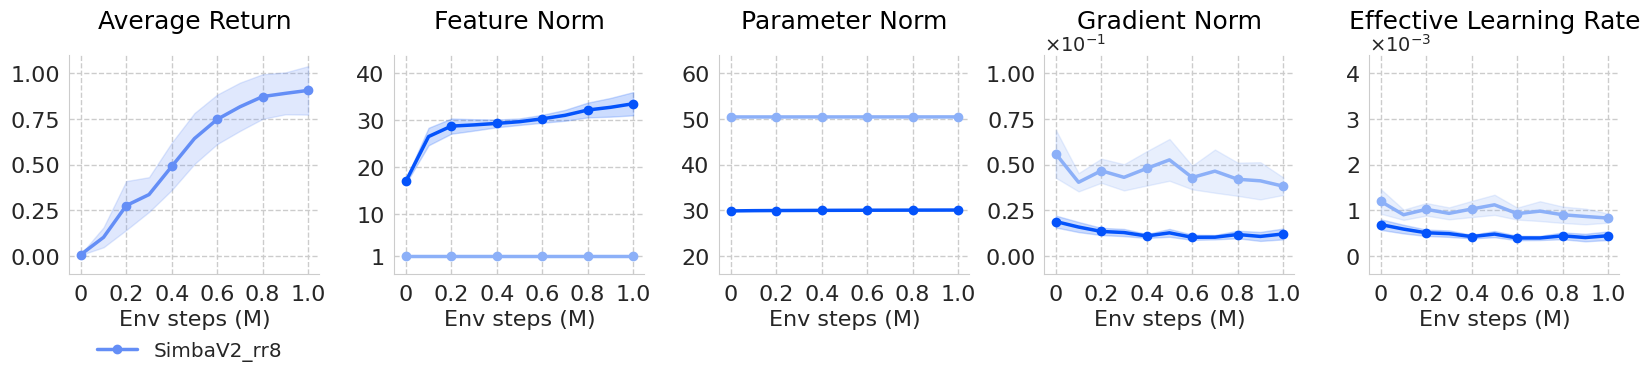

In [24]:
plot_analysis_metrics_total(
    eval_df,
    HB_LOCOMOTION_NOHAND,
    colors,
    metrics=['avg_return', 'effective_fnorm_total', 'effective_pnorm_total', 'effective_gnorm_total', 'effective_lr_total'],
    metrics_to_title=metrics_to_title,
    hspace=0.75,
    bbox_to_anchor_left=(0.185, -0.2),
    bbox_to_anchor_right=(0.575, -0.2),
    main_title="supplementary",
    columns=["SimbaV2_rr8"],
)